# Supply Chain Optimization

# 1. Problem Context and Objectives

1.1 Business Contex:

Modern e‑commerce supply chains operate under increasing pressure to deliver products quickly, reliably, and cost‑effectively. Late deliveries negatively affect customer satisfaction, increase operational costs, and damage brand reputation. As competition intensifies, organisations must leverage data analytics to identify inefficiencies, optimise logistics processes, and improve profitability.
The DataCo Smart Supply Chain dataset provides a rich, real‑world view of customer orders, shipping behaviour, product categories, delivery performance, and financial metrics. This makes it suitable for analysing operational bottlenecks and developing predictive models to support supply chain decision‑making.

1.2 Problem Definition:

The organisation faces recurring issues related to:
Late deliveries, Shipping delays, Regional performance inconsistencies, Profitability erosion, Lack of customer segmentation, Limited predictive capability for identifying high‑risk orders.  These challenges reduce operational efficiency and profitability.

1.3 Objectives:
* Evaluate factors affecting delivery performance and revenue across regions, products, and customer segments.
* Calculate Customer Lifetime Value (CLV) and segment customers.
* Predict late‑delivery risk using classification
* Build customer‑level segmentation using clustering
* Develop visual dashboards for operational decision‑making


# 2.Data Acquisition and Preparation (Python)

Dataset Description

The dataset used is DataCo Supply Chain Dataset, containing:
* Customer details
* Order information
* Product categories
* Shipping performance
* Profit and revenue metrics

Preparation Steps

* Selected relevant columns
* Cleaned hidden nulls, missing values and duplicates
* Converted date fields to datetime
* Extracted year, month, day
* Engineered features: Shipping_Delay_Risk, Profit Margin, Customer Lifetime Value (CLV)

These steps ensured the dataset was structured, consistent, and ready for analytics.

2.1 Import Libraries and Dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
import kagglehub
import os
path = kagglehub.dataset_download("shashwatwork/dataco-smart-supply-chain-for-big-data-analysis")
target_file = "DataCoSupplyChainDataset.csv"

# Join the download path with the filename
csv_path = os.path.join(path, target_file)
df = pd.read_csv(csv_path, encoding='ISO-8859-1')
df.head()

Using Colab cache for faster access to the 'dataco-smart-supply-chain-for-big-data-analysis' dataset.


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


2.2 Data Preparation

(Selecting necessary colomns, checking null values & missing values, checking duplicates, and converting date fields)

In [23]:
# Select necessary columns only
df = df[[
    "Customer Id",
    "Order Id",
    "order date (DateOrders)",
    "Customer Segment",
    "Product Name",
    "Category Name",
    "Department Name",
    "Order Item Product Price",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Total",
    "Order Profit Per Order",
    "Shipping Mode",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Order Region",
    "Order Country",
    "Delivery Status",
    "Late_delivery_risk",
    "Order Status"]]

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Customer Id                    180519 non-null  int64  
 1   Order Id                       180519 non-null  int64  
 2   order date (DateOrders)        180519 non-null  object 
 3   Customer Segment               180519 non-null  object 
 4   Product Name                   180519 non-null  object 
 5   Category Name                  180519 non-null  object 
 6   Department Name                180519 non-null  object 
 7   Order Item Product Price       180519 non-null  float64
 8   Order Item Quantity            180519 non-null  int64  
 9   Order Item Discount            180519 non-null  float64
 10  Order Item Total               180519 non-null  float64
 11  Order Profit Per Order         180519 non-null  float64
 12  Shipping Mode                 

,Customer Id,Order Id,order date (DateOrders),Customer Segment,Product Name,Category Name,Department Name,Order Item Product Price,Order Item Quantity,Order Item Discount,Order Item Total,Order Profit Per Order,Shipping Mode,Days for shipping (real),Days for shipment (scheduled),Order Region,Order Country,Delivery Status,Late_delivery_risk,Order Status
0,20755,77202,1/31/2018 22:56,Consumer,Smart watch,Sporting Goods,Fitness,327.75,1,13.110000,314.640015,91.250000,Standard Class,3,4,Southeast Asia,Indonesia,Advance shipping,0,COMPLETE
1,19492,75939,1/13/2018 12:27,Consumer,Smart watch,Sporting Goods,Fitness,327.75,1,16.389999,311.359985,-249.089996,Standard Class,5,4,South Asia,India,Late delivery,1,PENDING
2,19491,75938,1/13/2018 12:06,Consumer,Smart watch,Sporting Goods,Fitness,327.75,1,18.030001,309.720001,-247.779999,Standard Class,4,4,South Asia,India,Shipping on time,0,CLOSED
3,19490,75937,1/13/2018 11:45,Home Office,Smart watch,Sporting Goods,Fitness,327.75,1,22.940001,304.809998,22.860001,Standard Class,3,4,Oceania,Australia,Advance shipping,0,COMPLETE
4,19489,75936,1/13/2018 11:24,Corporate,Smart watch,Sporting Goods,Fitness,327.75,1,29.500000,298.250000,134.210007,Standard Class,2,4,Oceania,Australia,Advance shipping,0,PENDING_PAYMENT


In [24]:
# Checking for missing value
df.isnull().sum()

,0
Customer Id,0
Order Id,0
order date (DateOrders),0
Customer Segment,0
Product Name,0
Category Name,0
Department Name,0
Order Item Product Price,0
Order Item Quantity,0
Order Item Discount,0


In [25]:
# Checking hidden nulls
df.isin(["", " ", "NA", "N/A", "null"]).sum()

,0
Customer Id,0
Order Id,0
order date (DateOrders),0
Customer Segment,0
Product Name,0
Category Name,0
Department Name,0
Order Item Product Price,0
Order Item Quantity,0
Order Item Discount,0


In [26]:
# Checking Duplicates
df.duplicated().sum()

np.int64(0)

In [27]:
# Convert dates to proper datetime objects
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# Extract Year, Month and Day
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day

2.3 Feature Engineering

In [28]:
#1. Calculate Shipping_Delay_Risk
df['Shipping_Duration'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['Shipping_Delay_Risk'] = np.where(df['Shipping_Duration'] > 0, 1, 0)

In [29]:
#2. Calculate Profit Margin
df['profit_margin'] = df['Order Profit Per Order'] / df['Order Item Total']
df['Profitability'] = np.where(df['profit_margin'] > 0, 1, 0)

In [30]:
#3. Calculare Customer Lifetime Value (CLV): Identify loyal customers
# Number of Orders (unique)
order_df = df.groupby(
    ['Customer Id', 'Order Id', 'order date (DateOrders)']
).agg({
    'Order Item Total': 'sum'
}).reset_index()

#Calculate Customer Metrics
clv = order_df.groupby('Customer Id').agg({
    'Order Item Total': ['mean', 'count'],   # AOV + Frequency
    'order date (DateOrders)': ['min', 'max']
}).reset_index()

# Rename Columns
clv.columns = [
    'Customer Id',
    'Avg Order Value',
    'Purchase Frequency',
    'First Purchase',
    'Last Purchase']

# Calculate Customer Lifespan
clv['Customer Lifespan (Years)'] = (
    clv['Last Purchase'] - clv['First Purchase']
).dt.days / 365

# Avoid zero lifespan
clv['Customer Lifespan (Years)'] = clv[
    'Customer Lifespan (Years)'
].replace(0, 1/365)

# Calculate CLV
clv['CLV'] = (
    clv['Avg Order Value'] *
    clv['Purchase Frequency'] *
    clv['Customer Lifespan (Years)'])

# Merge the 'CLV' column
df = df.merge(clv[['Customer Id', 'CLV']], on='Customer Id', how='left')

df.head()

,Customer Id,Order Id,order date (DateOrders),Customer Segment,Product Name,Category Name,Department Name,Order Item Product Price,Order Item Quantity,Order Item Discount,...,Order Status,order_date,order_year,order_month,order_day,Shipping_Duration,Shipping_Delay_Risk,profit_margin,Profitability,CLV
0,20755,77202,2018-01-31 22:56:00,Consumer,Smart watch,Sporting Goods,Fitness,327.75,1,13.110000,...,COMPLETE,2018-01-31 22:56:00,2018,1,31,-1,0,0.290014,1,0.862027
1,19492,75939,2018-01-13 12:27:00,Consumer,Smart watch,Sporting Goods,Fitness,327.75,1,16.389999,...,PENDING,2018-01-13 12:27:00,2018,1,13,1,1,-0.800006,0,0.853041
2,19491,75938,2018-01-13 12:06:00,Consumer,Smart watch,Sporting Goods,Fitness,327.75,1,18.030001,...,CLOSED,2018-01-13 12:06:00,2018,1,13,0,0,-0.800013,0,0.848548
3,19490,75937,2018-01-13 11:45:00,Home Office,Smart watch,Sporting Goods,Fitness,327.75,1,22.940001,...,COMPLETE,2018-01-13 11:45:00,2018,1,13,-1,0,0.074998,1,0.835096
4,19489,75936,2018-01-13 11:24:00,Corporate,Smart watch,Sporting Goods,Fitness,327.75,1,29.500000,...,PENDING_PAYMENT,2018-01-13 11:24:00,2018,1,13,-2,0,0.449992,1,0.817123


# 3. Analytics Techniques and Modelling (Python)

3.1 Goal: Predict Late Delivery Risk from Logistic Regression

Features: numeric + categorical

Evaluation metrics: Accuracy, Precision, Recall, F1, ROC‑AUC
                    Confussion Metrix

Justification

Logistic Regression was chosen for predicting late delivery risk because:
* It is a well‑established method for binary classification.
* It handles mixed data types (categorical + numerical) effectively through one‑hot encoding.
* It provides interpretable coefficients, allowing the business to understand which factors influence late deliveries.
* It is computationally efficient for large datasets.

How it meets objectives
* Predicts which orders are likely to be delayed(By identifying potential delays before they occur, a business can protect its bottom-line profit through the reduction of expensive emergency shipping fees, penalties, and refund claims)
* Helps operations prioritise high‑risk shipments

Model Acurracy:

The classification model demonstrates a solid overall performance with an accuracy of approximately 70%. A standout feature of this model is its high Precision 85%. This is further supported by an ROC-AUC of 0.73, which indicates the model has a respectable ability to distinguish between the two classes.

Evaluation Matrix
* Class 0: The model is particularly efficient at capturing negative instances, showing a recall of 88% for Class 0. It rarely misses an actual negative case.

* Class 1: Conversely, the recall for Class 1 is lower at 54%. This suggests the model is conservative; while its positive predictions are accurate, it fails to identify nearly half of the actual positive cases.

* Balanced Metric: The F1-score of 0.66 highlights this trade-off between precision and recall.

The Confusion Matrix provides a detailed breakdown of the model's performance by comparing the Actual values against the Predicted values. With a total of 45,130 samples analyzed, the matrix reveals exactly where the model is succeeding and where it is stumbling:
* True Negatives (18,027): The model correctly identified these as Class 0. This is its strongest area, accurately capturing the bulk of the negative class.

* True Positives (13,405): The model correctly identified these as Class 1. While a high number, it is noticeably lower than the True Negatives.

* False Negatives (11,339): These are cases where the model predicted 0, but the actual value was 1. This "miss" rate is relatively high, probably reason to the lower Recall (54%) for Class 1.

* False Positives (2,359): These are cases where the model predicted 1, but the actual value was 0. The low number here is why the Precision (85%) is so strong—it rarely makes a "false alarm" when predicting Class 1.

Taking the metrics and the confusion matrix together, the overall performance characterizes a model that prioritizes precision over recall for the positive class.

Accuracy: 0.6964768446709506
Precision: 0.8503552397868561
Recall: 0.5417474943420627
F1 Score: 0.6618445739113261
ROC-AUC: 0.730590419842085

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     20386
           1       0.85      0.54      0.66     24744

    accuracy                           0.70     45130
   macro avg       0.73      0.71      0.69     45130
weighted avg       0.74      0.70      0.69     45130



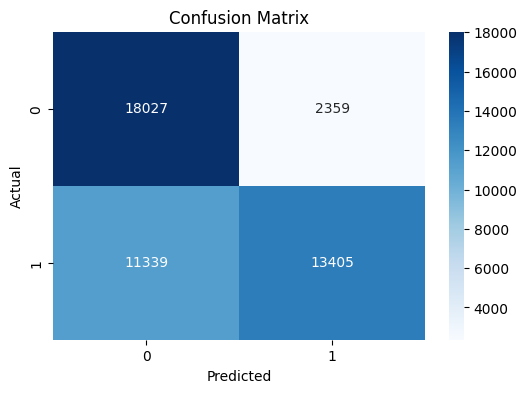

In [31]:
# Import Libraryies
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, classification_report
)

# Select Features
numeric_features = [
    'Days for shipment (scheduled)',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Discount',
    'Order Item Total',
    'Order Profit Per Order',
    'order_year', 'order_month', 'order_day',
]

categorical_features = [
    'Customer Segment',
    'Category Name',
    'Order Region',
    'Shipping Mode'
]

target = 'Late_delivery_risk'

X = df[numeric_features + categorical_features]
y = df[target]

# Preprocessing Pipeline
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Build Model Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=200, class_weight='balanced'))])

# Train & Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation Matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

3.2 Goal: Create Customer-Level (VIP / Regular / Risk) using K‑Means Clustering

Features used: Total Sales, Order Frequency, Avg Profit, Risk Ratio and CLV

Applied K‑Means (k=3)

Clusters labelled as:
* VIP Customer (high sales & profit)
* Regular Customer
* Risk Customer (high fraud/cancellation ratio)

Justification
K‑Means Clustering was selected for customer level creation because:
* There are no predefined customer labels, making unsupervised learning appropriate.
* K‑Means is scalable and efficient for large datasets.
* It groups customers based on behavioural metrics such as CLV, order frequency, and risk ratio.

How it meets objectives
* Enables differentiated service levels (e.g., faster delivery for VIP customers)
* Supports fraud detection and loyalty program optimisation
* Support targeted marketing strategies.

Output Visualisation Analysis

The chart clearly identifies VIP Customers (in orange) as the most valuable group, consistently exhibiting the highest Total Sales, Order Frequency, and Customer Lifetime Value (CLV) with relatively tight distributions.

Conversely, Risk Customers (in blue) show significantly lower engagement, particularly in CLV and Order Frequency, and interestingly, both Regular and Risk segments display a much wider spread in Avg_Profit, suggesting inconsistent profitability within those groups. This visualization effectively confirms that customer segmentation is well-defined, providing a strong foundation for targeted business strategies.

Customer_Level
Regular Customer    12647
VIP Customer         7486
Risk Customer         519
Name: count, dtype: int64


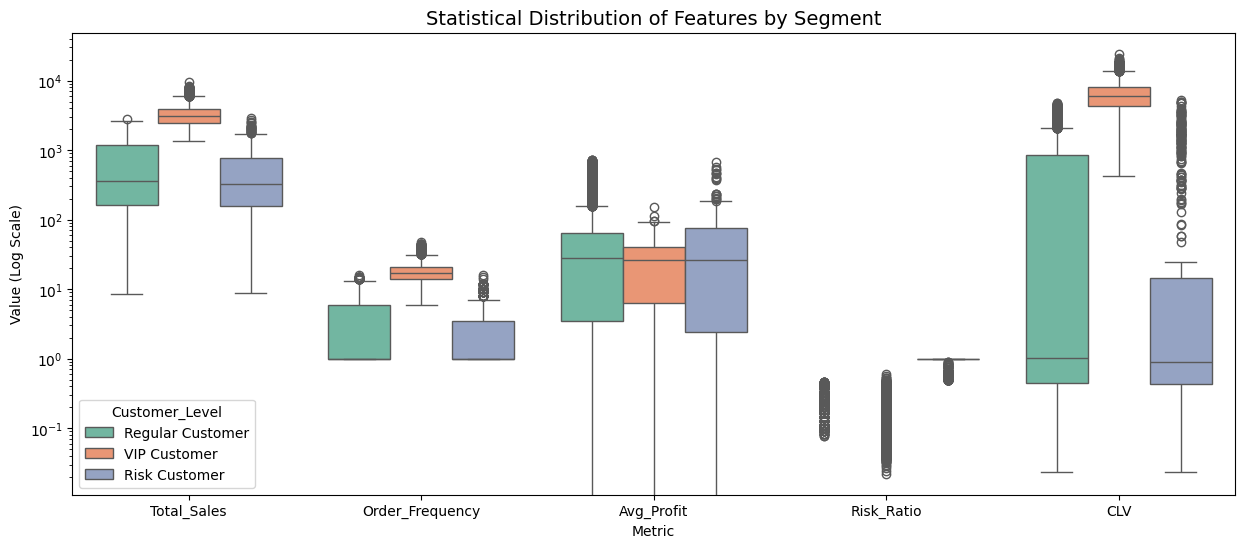

In [32]:
from sklearn.cluster import KMeans

# Capture risk orders from order satatus
risk_list = ['SUSPECTED_FRAUD', 'CANCELED']
df['is_risk_order'] = df['Order Status'].isin(risk_list).astype(int)

# Create Customer-Level Dataset from Selecting features and rename colomns
customer_df = df.groupby('Customer Id').agg({
    'Order Item Total': 'sum',
    'Order Id': 'count',
    'Order Profit Per Order': 'mean',
    'is_risk_order': 'mean',
    'CLV': 'mean'
}).rename(columns={
    'Order Item Total': 'Total_Sales',
    'Order Id': 'Order_Frequency',
    'Order Profit Per Order': 'Avg_Profit',
    'is_risk_order': 'Risk_Ratio'
}).reset_index()

# Scaling the Data
scaler = StandardScaler()
features = ['Total_Sales', 'Order_Frequency', 'Avg_Profit', 'Risk_Ratio', 'CLV']
customer_scaled = scaler.fit_transform(customer_df[features])

# Apply K-Means Clustering & get the actual cluster labels (0, 1, or 2)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(customer_scaled)

# 4. Labeling based on Cluster Means
summary = customer_df.groupby('Cluster')[features].mean()

# Mapping Logic: Assign Business Labels
# Find cluster with highest Risk_Ratio -> 'Risk Customer'
# Find cluster with highest Total_Sales -> 'VIP Customer'
# The remaining one -> 'Regular Customer'
risk_idx = summary['Risk_Ratio'].idxmax()
vip_idx = summary['Total_Sales'].idxmax()
regular_idx = [i for i in [0, 1, 2] if i not in [risk_idx, vip_idx]][0]

# Cluster Mapping
cluster_map = {
    risk_idx: 'Risk Customer',
    vip_idx: 'VIP Customer',
    regular_idx: 'Regular Customer'
}

# Add Labels to Dataset
customer_df['Customer_Level'] = customer_df['Cluster'].map(cluster_map)
df = df.merge(customer_df[['Customer Id', 'Customer_Level']], on='Customer Id', how='left')

# Print the count of each segment
print(customer_df['Customer_Level'].value_counts())

# Melt the data for easier plotting with Seaborn
melted_df = customer_df.melt(id_vars='Customer_Level', value_vars=features)

plt.figure(figsize=(15, 6))
sns.boxplot(data=melted_df, x='variable', y='value', hue='Customer_Level', palette='Set2')
plt.yscale('log') # Use log scale if Sales numbers are huge compared to Risk Ratio
plt.title("Statistical Distribution of Features by Segment", fontsize=14)
plt.ylabel("Value (Log Scale)")
plt.xlabel("Metric")
plt.show()

In [33]:
#3.3 Exported Preprocessed dataset to CSV and Excel
df.to_csv("cleaned_supply_chain.csv", index=False)
df.to_excel("cleaned_supply_chain.xlsx", index=False)

# 4.	Visualisation and Dashboard Development


4.1 Python Visualisations

The following visualisations were produced:

1. Shipping mode vs delivery status
2. Late_delivery_risk and Profit_margin by region
3. Correlation between Late_delivery_risk and Shipping_Delay_Risk
4. Sales & profit by category
5. Sales trend analyse

These visualisations support clear interpretation of supply chain performance.

a) Shipping Mode vs Delivery Status

This analysis compares how different shipping modes (Same Day, First Class, Second Class, Standard) perform in terms of on-time vs late deliveries. It helps identify whether faster or premium shipping options actually deliver better performance.

Business Impact
* Reveals whether premium shipping is worth the extra cost.
* Identifies shipping modes that frequently cause delays.
* Helps logistics teams renegotiate contracts with couriers or adjust delivery promises.

Visual Output

Late deliveries account for a majority (54.8%) of all orders. While "Standard Class" is the most utilized shipping mode at nearly 60%, the clustered bar chart reveals that it also carries the highest volume of late deliveries.

Interestingly, while "First Class" and "Second Class" modes are intended to be faster, they still show a high count of late deliveries relative to on-time shipments, suggesting that the "risk" of delay is prevalent across almost all service levels. Conversely, "Advance shipping" appears most successful within the Standard Class category, whereas "Same Day" shipping maintains a very small footprint with a nearly equal split between late and on-time status. Overall, the data points toward a systemic bottleneck in the delivery process  about chosen specific shipping methods.

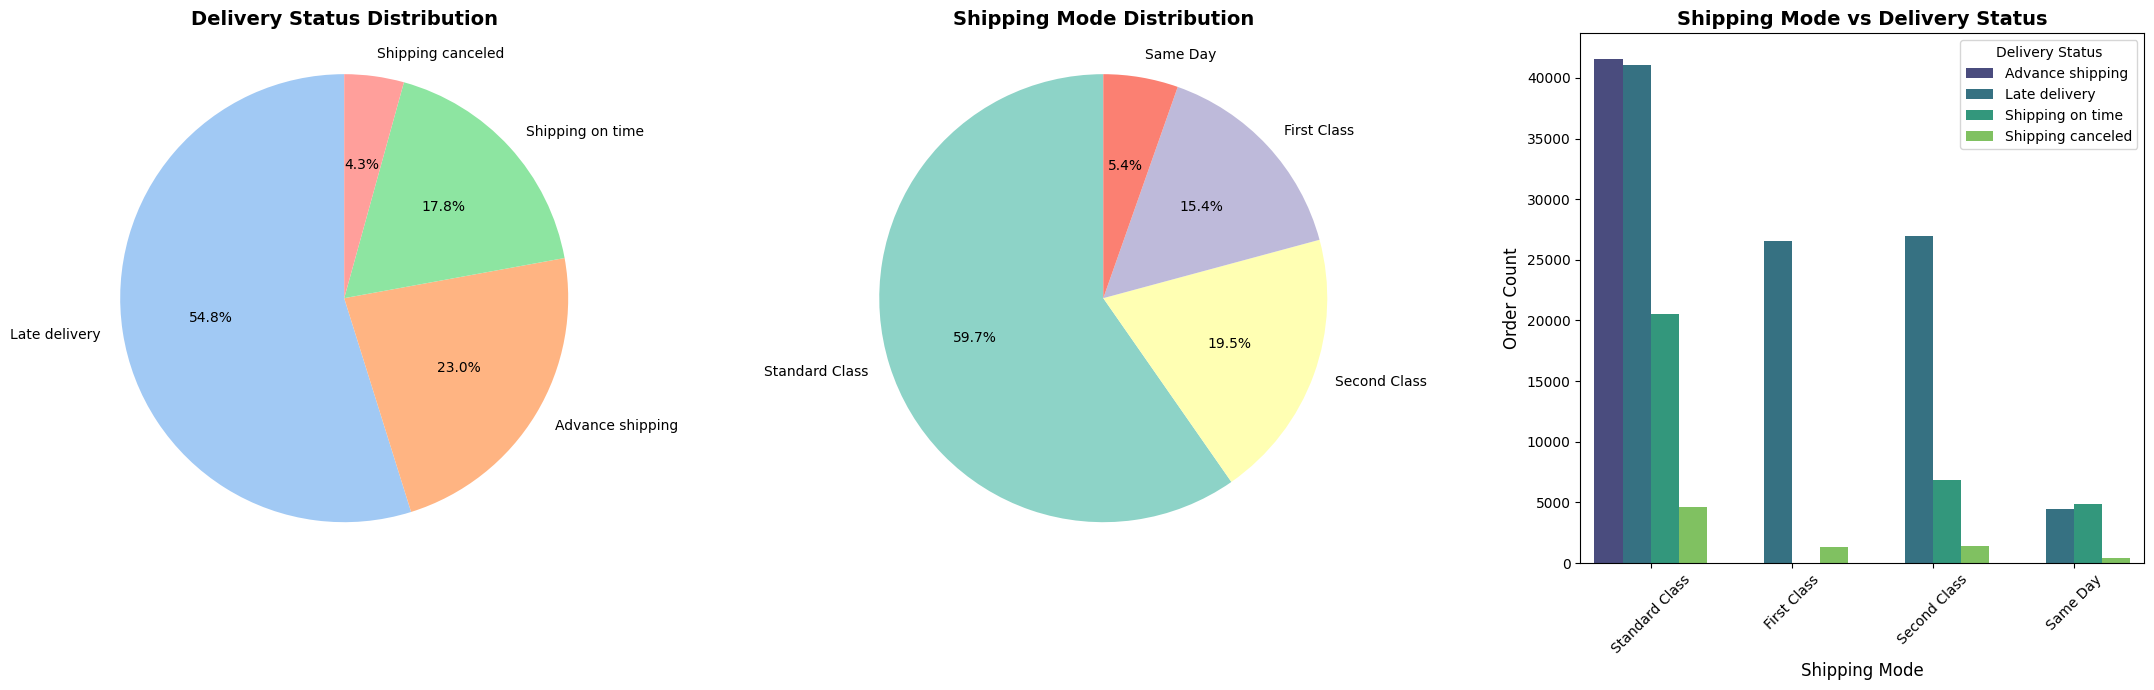

In [34]:
# Create a figure with three subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Delivery Status Distribution (Left)
status_counts = df['Delivery Status'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('pastel'))
axes[0].set_title("Delivery Status Distribution", fontsize=14, fontweight='bold')
axes[0].axis('equal')

# Shipping Mode Distribution (Middle)
mode_counts = df['Shipping Mode'].value_counts()
axes[1].pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set3'))
axes[1].set_title("Shipping Mode Distribution", fontsize=14, fontweight='bold')
axes[1].axis('equal')

# Shipping Mode vs Delivery Status (Right)
sns.countplot(data=df, x='Shipping Mode', hue='Delivery Status', ax=axes[2], palette='viridis')
axes[2].set_title("Shipping Mode vs Delivery Status", fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_xlabel("Shipping Mode", fontsize=12)
axes[2].set_ylabel("Order Count", fontsize=12)

plt.tight_layout()
plt.show()

b) Late_delivery_risk and Profit_margin by region

This combines two metrics: Number of late deliveries per region & average profit margin per region. This highlights regions that are profitable but operationally risky.

Business Impact
* Identifies High Late_delivery_risk operational regions.
* Helps prioritize investment in regional warehouses or carrier partnerships.
* Protects revenue by improving logistics where it matters most.

Visual Output

Central America and Western Europe stand out with the highest volume of late deliveries, exceeding 15,000 cases each, while maintaining moderate profit margins. In contrast, regions with much lower late delivery volumes, such as Southern Africa and Canada, exhibit significantly higher average profit margins, suggesting that operational efficiency in these smaller markets correlates with better financial health.


/tmp/ipykernel_5241/3254302609.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y=comparison_df['Late Delivery Count'],
/tmp/ipykernel_5241/3254302609.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


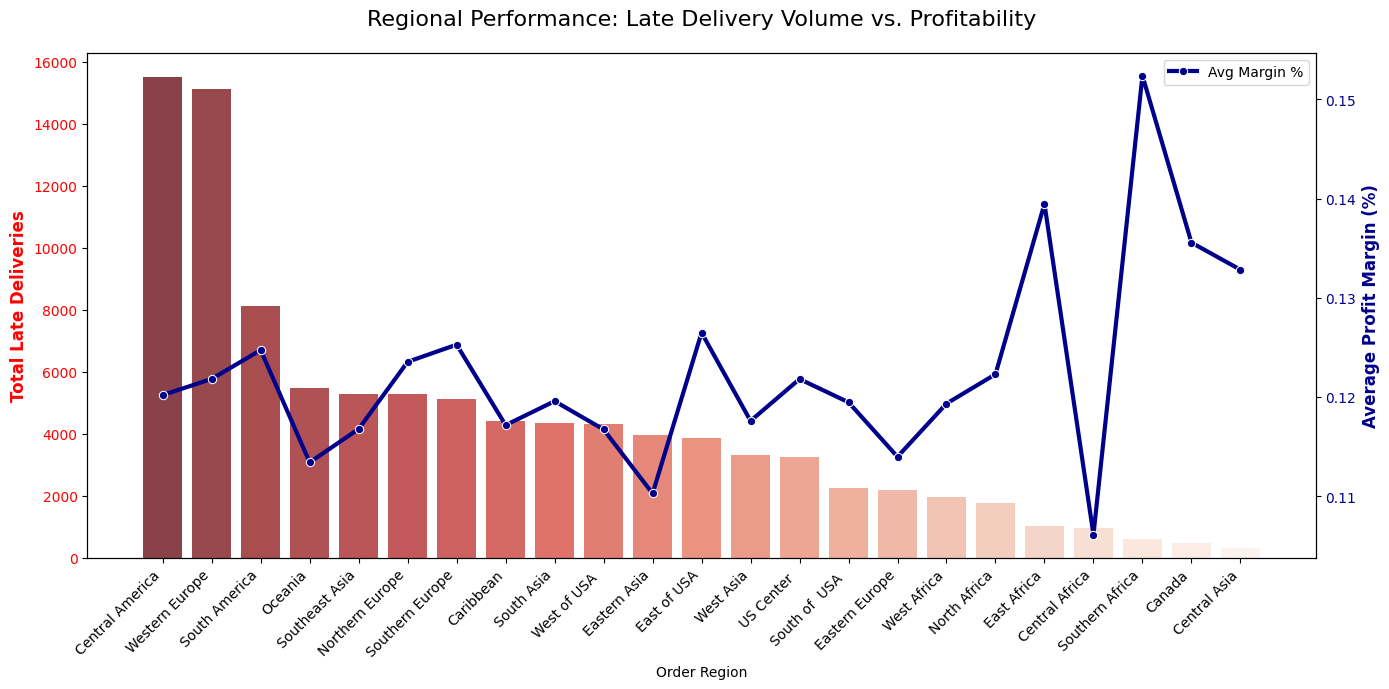

In [35]:
# Filter for Late Deliveries & Groups them by Order Region
late_counts = df[df['Late_delivery_risk'] == 1]['Order Region'].value_counts()

# Calculate Average Profit Margin
margin_avg = df.groupby("Order Region")["profit_margin"].mean().sort_values(ascending=False)

# Create a combined dataframe for plotting
comparison_df = pd.DataFrame({
    'Late Delivery Count': late_counts,
    'Avg Profit Margin': margin_avg
}).sort_values(by='Late Delivery Count', ascending=False)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar Chart: Total Late Deliveries
sns.barplot(x=comparison_df.index, y=comparison_df['Late Delivery Count'],
            ax=ax1, palette='Reds_r', alpha=0.8)
ax1.set_ylabel('Total Late Deliveries', color='red', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Line Chart: Average Profit Margin (Overlay)
ax2 = ax1.twinx() # Create the second axis
sns.lineplot(x=comparison_df.index, y=comparison_df['Avg Profit Margin'],
             ax=ax2, color='darkblue', marker='o', linewidth=3, label='Avg Margin %')
ax2.set_ylabel('Average Profit Margin (%)', color='darkblue', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkblue')

plt.title("Regional Performance: Late Delivery Volume vs. Profitability", fontsize=16, pad=20)
fig.tight_layout()
plt.show()

c) Correlation between Late_delivery_risk and Shipping_Delay_Risk

This uses a correlation matrix (Heatmap) to checks whether shipping delays are related to final delivery delays.

Business Impact
* Increase safety stock in local warehouses for risk areas.
* Supports faster decision-making by highlighting high-risk shipments early.
* Improves performance evaluation of shipping providers and logistics partners.

Visual Output

The heatmap reveals a near-perfect positive correlation (0.95) between Late_delivery_risk and Shipping_Delay_Risk. This extremely high coefficient indicates that these two variables are moving almost entirely in pairly same; as the risk of a shipping delay increases, the risk of a late delivery follows suit with near-certainty.

From a modeling perspective, such a high correlation suggests that these features are highly redundant. In short,shipping delays are the primary driver of late deliveries.

Correlation: 0.9514739201289272
                     Late_delivery_risk  Shipping_Delay_Risk
Late_delivery_risk             1.000000             0.951474
Shipping_Delay_Risk            0.951474             1.000000


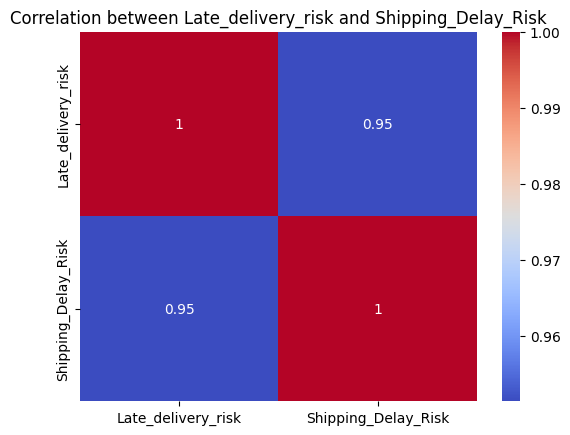

In [36]:
correlation = df['Late_delivery_risk'].corr(df['Shipping_Delay_Risk'])
print("Correlation:", correlation)

#creat a Correlation Matrix
corr_matrix = df[['Late_delivery_risk', 'Shipping_Delay_Risk']].corr()
print(corr_matrix)

#Plot heat map
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between Late_delivery_risk and Shipping_Delay_Risk")
plt.show()

d) Sales & profit by Product category

A grouped bar chart was used to compare total sales and total profit across different product categories.This makes it easy to compare high-sales categories, high-profit categories, categories with high sales but low profit.

Business Impact:
* Identify top‑performing categories
* Supports decisions on inventory planning

Visual Output

Fishing is the absolute leader, boasting over 6M in sales. It also shows the highest total profit, making it the most vital category for the business. Cleats, Camping & Hiking, and Cardio Equipment are the "second tier," with sales ranging between 3M and 4M. Water Sports and Women's Apparel are also high-performers, consistently hitting near the 3M sales mark. However, most of the product categories are under 1M sales. This highlights the business carries many low Low-selling products that don't drive significant volume of total revenue.

While sales fluctuate wildly between categories, the profit appears more low level across the top-performing categories.
There may be diminishing returns or higher logistics costs associated with the highest-volume items.





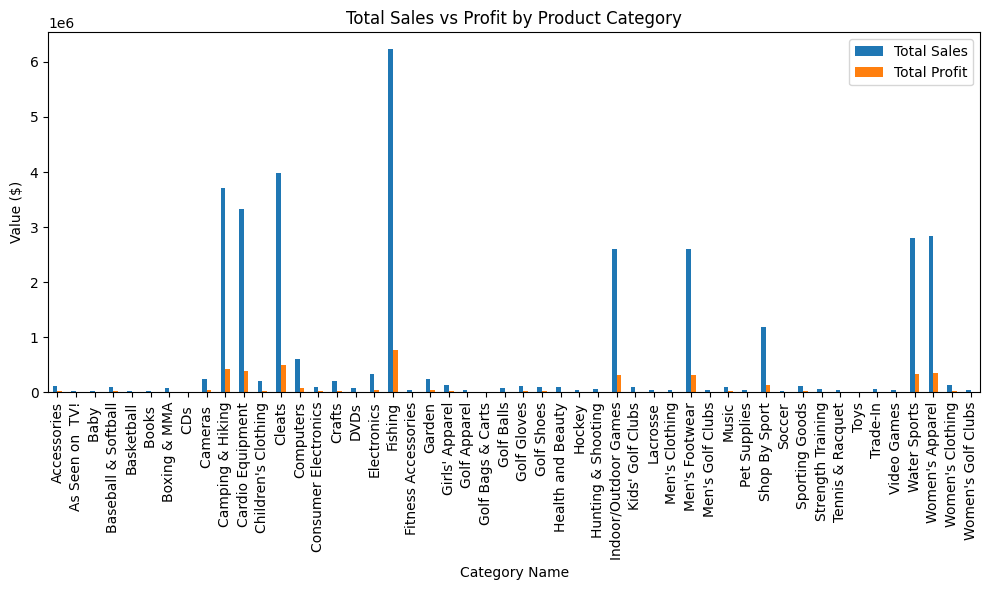

In [37]:
# Group data by category and rename column names
summary = df.groupby('Category Name').agg({
    'Order Item Total': 'sum',
    'Order Profit Per Order': 'sum'
}).rename(columns={'Order Item Total': 'Total Sales',
                   'Order Profit Per Order': 'Total Profit'})

# Plot
summary.plot(kind='bar', figsize=(10, 6))
plt.title('Total Sales vs Profit by Product Category')
plt.ylabel('Value ($)')
plt.tight_layout()
plt.show()

e) Sales trend analyse

This analyse monthly sales over multiple years. This highlights seasonal trends and year‑over‑year performance.

Business Impact:
* Supports revenue forecasting & Seasonal planning
* Identifies peak months for staffing and inventory

Visualisation Outcome:

The chart tracks total sales across four years (2015–2018). Year 2015 and 2016 show relatively stable, consistent demand. This indicates a predictable market where supply likely met demand with standard safety stock levels. Meanwhile, 2017 started strong, peaking in September. However, it was suddenly drop in November and December, possibly due to operational issues, supply chain disruptions, or market changes. The 2018 "Incomplete": there is only one data point for January 2018, sitting at a low $300k.

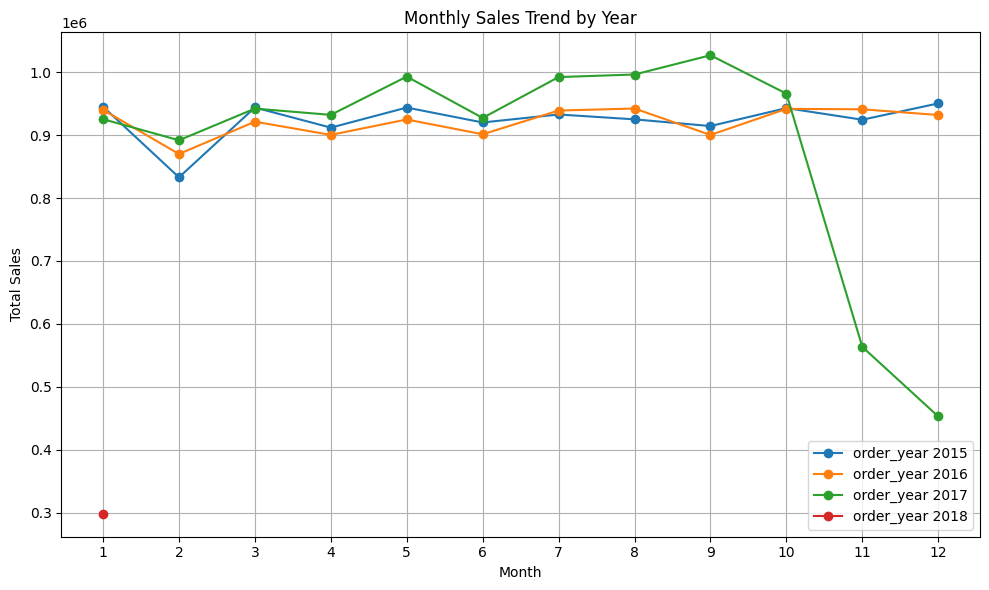

In [38]:
# Aggregate sales by month
monthly_sales = df.groupby(['order_year', 'order_month'])['Order Item Total'].sum().reset_index()

# Plot
plt.figure(figsize=(10,6))

for year in monthly_sales['order_year'].unique():
    data = monthly_sales[monthly_sales['order_year'] == year]
    plt.plot(data['order_month'], data['Order Item Total'], marker='o', label=f'order_year {year}')

plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(range(1,13))
plt.grid()

plt.tight_layout()
plt.show()

4.2 Development of a dashboard

Overall Dashboard Summary

The dashboard provides a comprehensive analysis of sales performance, customer behavior, delivery efficiency, geographical trends, and sales growth over time. The purpose of the dashboard is to help management identify high-performing categories, profitable customer segments, operational bottlenecks(Bottlenecks are problem areas that limit productivity, increase delays, or affect business performance.), and opportunities for business growth.

The analysis combines multiple perspectives:
* Delivery and logistics efficiency
* Customer purchasing patterns
* Product category performance
* Sales and profitability trends
* Regional sales distribution
* Time-based sales growth

**a) KPI (Key Performance Indicator) Insights**

The dashboard includes KPI tooltips that summarize important business metrics.

Common KPIs Monitored
* Total Sales
* Total Profit
* Profitability
* Customer Count
* Delivery status
* Order Volume
* Sales Growth Percentage

Importance of KPIs

KPIs provide quick performance visibility and help management:
* Monitor business health
* Compare current vs previous performance
* Track operational efficiency
* Support strategic decision-making

**b) Delivery Performance Analysis**

Key Findings

The delivery performance dashboard measures operational efficiency and shipping performance.

Insights
* Delayed deliveries negatively affect customer satisfaction.
* Some shipping methods perform better in terms of delivery speed and reliability.
* Delivery delays may vary across regions.
* Faster delivery often improves customer retention and repeat purchases.

Business Interpretation

The company can use this analysis to:
* Improve logistics planning
* Reduce delivery delays
* Enhance customer experience
* Optimize shipping methods

Recommendation
* Improve coordination with logistics partners.
* Monitor regions with frequent delivery delays.
* Promote efficient shipping methods.
* Use predictive analysis to manage delivery risks.

**c) Customer Analysis**

Key Findings

The customer analysis evaluates customer contribution to total sales and profitability.

Business Interpretation

This analysis helps identify:
* Loyal customers
* High-value customers
* Customers requiring retention strategies
* Opportunities for personalized marketing

Recommendation
* Introduce loyalty programs for top customers.
* Target high-frequency customers with premium offerings.
* Encourage low-frequency customers through promotional campaigns.
* Improve engagement with inactive customers.

**d) Categorical Sales Analysis**

Key Findings

The categorical sales analysis focuses on comparing product categories and sub-categories to determine which products generate the highest revenue and profit.

Business Interpretation
* Prioritize profitable product categories
* Reduce focus on low-margin products
* Improve inventory planning
* Develop targeted marketing strategies

Recommendation
* Increase promotions for high-profit categories.
* Review pricing and discount strategies for low-margin products.
* Remove or redesign weak-performing product lines.

**e) Geographical Sales Analysis**

Key Findings

The geographical analysis identifies regional sales distribution and market performance.

Insights
* Certain regions contribute the highest sales and profits.
* Some areas have strong sales but low profitability.
* Emerging regions show growth potential but may require additional marketing investment.
* Regional customer preferences may differ significantly.

Business Interpretation

This analysis helps management:
* Identify high-performing markets
* Detect underperforming regions
* Allocate resources effectively
* Plan regional expansion strategies

Recommendation
* Increase investment in high-growth regions.
* Improve marketing in weak-performing locations.
* Customize product offerings based on regional demand.

**f) Sales Trend Analysis**

Key Findings

The sales trend analysis evaluates business growth over time.

Insights
* Sales fluctuate across different months and seasons.
* Peak sales periods indicate strong seasonal demand.
* Some periods show declining sales trends that may require investigation.
* Long-term trends help identify overall business growth patterns.

Business Interpretation

This analysis supports:
* Forecasting future sales
* Identifying seasonal trends
* Planning inventory and staffing
* Monitoring business growth

Recommendation
* Prepare inventory in advance for peak sales periods.
* Launch campaigns during low-sales months.
* Use historical trends for forecasting and budgeting.

#5. Critical Reflection

5.1 Quality of the Analytics Solution

The project successfully combined data preprocessing, statistical insights, machine learning, exploratory analysis
and dashboard visualisation. The solution provides actionable insights for operational and strategic decision-making.


5.2 Limitations:
* Feature redundancy: Shipping_Delay_Risk and Late_delivery_risk are highly correlated (0.95), which may inflate model performance.
* Class imbalance: Logistic Regression may not capture highly complex patterns. Although class weighting was applied, the model still struggles with recall for the positive class.
* Some variables may contain hidden bias or missing context.
* Real-world supply chains are affected by external factors (weather, fuel prices) not present in this dataset.
* The dataset does not contain real-time updates.

5.3 Assumptions:
* Assumed that past "Suspected Fraud" is a reliable indicator of future "Risk" customers.
* Sales and delivery records are complete and up to date.

5.4 Potential Improvements:
* Addition of real-time data connectivity for live monitoring.
* Incorporation of customer demographic and behavioural data.
* Development of automated alerts for delivery delays or sales anomalies.
* Improved dashboard accessibility and user guidance for non-technical stakeholders.
* Inclusion of benchmarking against industry standards or competitor performance.
* Monitor KPIs regularly to support data-driven decisions.

5.5 Ethical, legal, or governance considerations:
* Privacy: Customer IDs were used instead of names to maintain anonymity (GDPR compliance).
* The "Risk" model must be used carefully to avoid unfairly "blacklisting" honest customers in specific regions who might face shipping delays outside their control.

#6. Conclusion

Overall, the analytics solution provides valuable descriptive insights into sales, customer behaviour, delivery performance, and regional trends. While the dashboard effectively supports operational and strategic decision-making, its effectiveness depends on data quality, user interpretation, and ongoing maintenance. Future enhancements involving predictive analytics, real-time integration, and stronger governance practices could significantly improve the overall value and reliability of the solution.